# v11 — Trailing Stop: kunci profit begitu posisi sudah untung

**Latar belakang:** live trading yang WIN biasanya profit $10-15, tapi harga sempat lewatin
level tertentu (mis. $8) sebelum akhirnya closing. Pertanyaan: kalau SL digeser naik begitu
profit unrealized mencapai threshold tertentu (mis. profit $8 -> SL naik ke $4 keuntungan
terkunci), apakah itu membantu (mengunci profit sebelum market berbalik) atau malah merugikan
(memotong trade yang harusnya lanjut ke TP penuh)?

**Baseline:** strategi final yang sudah divalidasi — v06 (signal scoring + TP/SL ATR-relatif
SL=2x/TP=4x) **+ v10 SKIP** (skip entry kalau ada Order Block SMC lawan arah sinyal, terbukti
lebih baik dari REVERSE & SMALL-REVERSE di validasi train/test sebelumnya).

**Metodologi:**
1. Backtest ulang v06+SKIP dengan candle-by-candle price path tracking -- catat kapan & seberapa
   tinggi profit unrealized (`max_favorable`) tercapai SEBELUM exit final (TP/SL/TIMEOUT)
2. Simulasikan beberapa varian trailing stop (threshold aktivasi & jarak lock berbeda-beda),
   replay ULANG posisi tsb dengan aturan trailing -- BUKAN cuma re-label data lama, karena
   trailing mengubah kapan/di harga berapa exit terjadi
3. Split TRAIN (2025-01 s/d 2026-02) untuk cari parameter trailing yang masuk akal, TEST
   (2026-03 s/d 2026-08, out-of-sample) untuk validasi independen -- ikuti disiplin yang sama
   dgn v10 supaya tidak overfitting
4. Bandingkan: tanpa trailing (baseline) vs beberapa varian trailing -- net PnL, win rate,
   berapa trade yang "harusnya" TP penuh tapi malah closing lebih awal krn trailing

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v11"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (sama seperti v02-v10)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

print("M5 + konteks H1:", df.shape, df["datetime"].min(), "->", df["datetime"].max())

M5 + konteks H1: (518403, 159) 2019-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Generate sinyal (parameter v06, TIDAK diubah) + split TRAIN/TEST

In [3]:
BACKTEST_START = "2025-01-01"
TRAIN_END = "2026-03-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)

MIN_SIGNAL_SCORE = 9.0
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03
REQUIRE_H1_ALIGNMENT = True
SL_MULT = 2.0
TP_MULT = 4.0
MAX_HOLD_CANDLES = 12

directions = np.empty(len(df_bt), dtype=object)
scores = np.zeros(len(df_bt))
for pos, (_, row) in enumerate(df_bt.iterrows()):
    result = generate_signal(row, MIN_SIGNAL_SCORE, ADX_MIN, ATR_MIN_PCT, REQUIRE_H1_ALIGNMENT)
    directions[pos] = result.direction
    scores[pos] = result.final_score

df_bt["signal_direction"] = directions
df_bt["signal_score"] = scores

df_train = df_bt[df_bt["datetime"] < TRAIN_END].reset_index(drop=True)
df_test = df_bt[df_bt["datetime"] >= TRAIN_END].reset_index(drop=True)
print(f"TRAIN: {len(df_train)} baris, {df_train['datetime'].min()} -> {df_train['datetime'].max()}")
print(f"TEST : {len(df_test)} baris, {df_test['datetime'].min()} -> {df_test['datetime'].max()}")

TRAIN: 77226 baris, 2025-01-01 23:00:00+00:00 -> 2026-02-27 21:55:00+00:00
TEST : 30110 baris, 2026-03-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 3. Backtest engine — v06 + SKIP order block (baseline final) + opsi trailing stop

`trailing_activate_mult` & `trailing_lock_mult`: dalam satuan kelipatan ATR (bukan poin fixed,
konsisten dgn cara SL/TP dihitung). Begitu profit unrealized >= `trailing_activate_mult * ATR`,
SL digeser ke level yang mengunci `trailing_lock_mult * ATR` dari entry (bukan dari harga saat
ini -- SL cuma naik sekali per threshold, direplikasi sederhana: begitu lock level tercapai,
SL dipindah ke situ dan TIDAK diturunkan lagi kalau harga mundur dikit).

In [4]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def has_opposing_ob(row: pd.Series, direction: str) -> bool:
    if direction == "BUY":
        return bool(row["ob_bear"] > 0 or row["h1_ob_bear"] > 0)
    return bool(row["ob_bull"] > 0 or row["h1_ob_bull"] > 0)


def run_backtest(
    df_signals: pd.DataFrame, sl_mult: float, tp_mult: float, max_hold_candles: int,
    trailing_activate_mult: float | None = None, trailing_lock_mult: float | None = None,
    save_full_log: bool = False,
) -> tuple[pd.DataFrame, list[float]]:
    """trailing_activate_mult=None -> tanpa trailing (baseline murni v06+SKIP).
    Kalau di-set, begitu profit unrealized (dlm satuan ATR entry) >= trailing_activate_mult,
    SL dipindah SEKALI ke level yang mengunci trailing_lock_mult x ATR keuntungan dari entry."""
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        if has_opposing_ob(row, direction):
            i += 1
            continue

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = sl_mult * atr
        tp_points = tp_mult * atr
        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price: float | None = None
        exit_time = None
        exit_reason = None
        max_favorable_pts = 0.0
        trailing_activated = False
        cur_sl_price = sl_price
        exit_idx = min(i + max_hold_candles, n - 1)  # fallback TIMEOUT candle, selalu terdefinisi

        trailing_activate_pts = trailing_activate_mult * atr if trailing_activate_mult else None
        trailing_lock_pts = trailing_lock_mult * atr if trailing_lock_mult else None

        window_end = min(i + 1 + max_hold_candles, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]

            unrealized = (candle["high"] - entry_price) if direction == "BUY" else (entry_price - candle["low"])
            if unrealized > max_favorable_pts:
                max_favorable_pts = unrealized

            if trailing_activate_pts is not None and not trailing_activated and unrealized >= trailing_activate_pts:
                trailing_activated = True
                if direction == "BUY":
                    cur_sl_price = entry_price + trailing_lock_pts
                else:
                    cur_sl_price = entry_price - trailing_lock_pts

            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= cur_sl_price if direction == "BUY" else candle["high"] >= cur_sl_price

            if hit_sl:
                exit_price = cur_sl_price
                exit_time = candle["datetime"]
                exit_reason = "TRAILING_SL" if trailing_activated else "SL"
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                exit_idx = candle_idx
                break

        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"

        next_i = exit_idx + 1
        hold_candles = exit_idx - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price,
            "sl_price_original": sl_price, "sl_price_used": cur_sl_price,
            "atr_at_entry": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "trailing_activated": trailing_activated,
            "max_favorable_pts": max_favorable_pts, "max_favorable_atr": max_favorable_pts / atr,
            "signal_score": row["signal_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}
    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

## 4. Baseline TRAIN: v06 + SKIP order block, TANPA trailing

In [5]:
trades_train_baseline, _ = run_backtest(df_train, SL_MULT, TP_MULT, MAX_HOLD_CANDLES)
metrics_train_baseline = evaluate(trades_train_baseline, INITIAL_EQUITY)
print("=== TRAIN baseline (v06 + SKIP order block, tanpa trailing) ===")
for k, v in metrics_train_baseline.items():
    print(f"  {k}: {v}")

=== TRAIN baseline (v06 + SKIP order block, tanpa trailing) ===
  total_trades: 785
  win_rate_pct: 62.55
  profit_factor: 2.43
  net_pnl: 3057.58
  final_equity: 3157.58
  max_drawdown_pct: -8.17
  min_equity: 91.83
  trading_days: 246
  avg_daily_pnl: 12.43
  avg_trades_per_day: 3.19


## 5. Analisis price path: seberapa tinggi profit unrealized tercapai sebelum exit final?

Ini jawaban langsung atas pertanyaan "trade yang WIN itu sempat naik berapa tinggi sebelum akhirnya
closing" -- dari trade log TANPA trailing (jadi murni menggambarkan price path asli).

In [6]:
wins_train = trades_train_baseline[trades_train_baseline["pnl"] > 0]
losses_train = trades_train_baseline[trades_train_baseline["pnl"] <= 0]

print("=== Trade WIN: max_favorable_atr tercapai sebelum exit (vs realized profit) ===")
print(wins_train[["max_favorable_atr"]].describe())
print()
print("Realized pnl WIN (median, mean):", wins_train["pnl"].median(), wins_train["pnl"].mean())
print()
print("=== Trade LOSS: max_favorable_atr tercapai sebelum akhirnya closing rugi (jendela yg 'terlewat') ===")
print(losses_train[["max_favorable_atr"]].describe())
print()
# berapa % trade LOSS yang SEMPAT profit signifikan (>=1x ATR) sebelum berbalik jadi rugi
for th in [0.5, 1.0, 1.5, 2.0]:
    pct = (losses_train["max_favorable_atr"] >= th).mean() * 100
    print(f"Trade LOSS yang sempat profit unrealized >= {th}x ATR: {pct:.1f}%")

=== Trade WIN: max_favorable_atr tercapai sebelum exit (vs realized profit) ===
       max_favorable_atr
count         491.000000
mean            2.998012
std             1.522209
min             0.169009
25%             1.840724
50%             2.820191
75%             4.023804
max            14.989773

Realized pnl WIN (median, mean): 6.699999999999819 10.57869404501695

=== Trade LOSS: max_favorable_atr tercapai sebelum akhirnya closing rugi (jendela yg 'terlewat') ===
       max_favorable_atr
count         294.000000
mean            1.007147
std             0.804093
min             0.000000
25%             0.365524
50%             0.874839
75%             1.424194
max             5.340233

Trade LOSS yang sempat profit unrealized >= 0.5x ATR: 69.0%
Trade LOSS yang sempat profit unrealized >= 1.0x ATR: 43.5%
Trade LOSS yang sempat profit unrealized >= 1.5x ATR: 22.8%
Trade LOSS yang sempat profit unrealized >= 2.0x ATR: 11.9%


## 6. Grid search trailing stop di TRAIN

`trailing_activate_mult`: threshold profit (x ATR) yang men-trigger trailing.
`trailing_lock_mult`: seberapa besar profit yang dikunci (x ATR) begitu trailing aktif.

In [7]:
activate_candidates = [1.0, 1.5, 2.0, 2.5, 3.0]
lock_candidates = [0.25, 0.5, 1.0, 1.5]

grid_results = []
for act in activate_candidates:
    for lock in lock_candidates:
        if lock >= act:
            continue  # lock harus < activate (gak masuk akal kunci lebih dari threshold aktivasi)
        trades, _ = run_backtest(df_train, SL_MULT, TP_MULT, MAX_HOLD_CANDLES,
                                  trailing_activate_mult=act, trailing_lock_mult=lock)
        metrics = evaluate(trades, INITIAL_EQUITY)
        n_trailing_hit = (trades["exit_reason"] == "TRAILING_SL").sum()
        n_activated = trades["trailing_activated"].sum()
        metrics.update({
            "activate_mult": act, "lock_mult": lock,
            "n_trailing_activated": int(n_activated), "n_trailing_sl_hit": int(n_trailing_hit),
        })
        grid_results.append(metrics)

grid_df = pd.DataFrame(grid_results).sort_values("final_equity", ascending=False)
print(f"Baseline TRAIN (tanpa trailing): final_equity={metrics_train_baseline['final_equity']}, "
      f"net_pnl={metrics_train_baseline['net_pnl']}, max_dd={metrics_train_baseline['max_drawdown_pct']}%")
print()
print("=== Grid search TRAIN: top 10 kombinasi trailing ===")
grid_df.head(10)

Baseline TRAIN (tanpa trailing): final_equity=3157.58, net_pnl=3057.58, max_dd=-8.17%

=== Grid search TRAIN: top 10 kombinasi trailing ===


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,activate_mult,lock_mult,n_trailing_activated,n_trailing_sl_hit
13,787,63.02,2.35,2649.42,2749.42,-8.37,91.83,247,10.73,3.19,3.0,0.25,233,27
14,788,63.32,2.35,2535.23,2635.23,-8.55,91.52,247,10.26,3.19,3.0,0.50,235,45
9,793,63.56,2.28,2426.13,2526.13,-9.88,91.83,247,9.82,3.21,2.5,0.25,302,56
10,799,63.70,2.22,2246.51,2346.51,-10.28,91.52,248,9.06,3.22,2.5,0.50,304,81
15,793,63.30,2.21,2216.06,2316.06,-9.61,91.83,247,8.97,3.21,3.0,1.00,237,83
5,810,66.30,2.14,2027.80,2127.80,-11.66,90.94,248,8.18,3.27,2.0,0.25,392,143
16,800,63.50,2.07,1919.17,2019.17,-9.40,91.83,247,7.77,3.24,3.0,1.50,239,123
11,807,63.69,2.03,1852.12,1952.12,-9.95,91.83,248,7.47,3.25,2.5,1.00,309,142
6,820,66.95,2.06,1840.00,1940.00,-10.89,90.42,248,7.42,3.31,2.0,0.50,398,183
8,881,66.86,1.89,1609.36,1709.36,-9.63,91.15,249,6.46,3.54,2.0,1.50,429,401


## 7. Validasi di TEST (2026-03 s/d 2026-08, out-of-sample) — parameter FIXED dari TRAIN

In [8]:
trades_test_baseline, curve_test_baseline = run_backtest(df_test, SL_MULT, TP_MULT, MAX_HOLD_CANDLES)
metrics_test_baseline = evaluate(trades_test_baseline, INITIAL_EQUITY)

best_row = grid_df.iloc[0]
ACTIVATE_MULT = float(best_row["activate_mult"])
LOCK_MULT = float(best_row["lock_mult"])
print(f"Parameter terpilih dari TRAIN: activate={ACTIVATE_MULT}x ATR, lock={LOCK_MULT}x ATR")

trades_test_trailing, curve_test_trailing = run_backtest(
    df_test, SL_MULT, TP_MULT, MAX_HOLD_CANDLES,
    trailing_activate_mult=ACTIVATE_MULT, trailing_lock_mult=LOCK_MULT, save_full_log=True,
)
metrics_test_trailing = evaluate(trades_test_trailing, INITIAL_EQUITY)

comparison_test = pd.DataFrame({
    "TEST — baseline (tanpa trailing)": metrics_test_baseline,
    f"TEST — trailing (act={ACTIVATE_MULT}x, lock={LOCK_MULT}x)": metrics_test_trailing,
})
print("\n=== Perbandingan TEST set (out-of-sample) ===")
comparison_test

Parameter terpilih dari TRAIN: activate=3.0x ATR, lock=0.25x ATR



=== Perbandingan TEST set (out-of-sample) ===


,TEST — baseline (tanpa trailing),"TEST — trailing (act=3.0x, lock=0.25x)"
total_trades,315.00,318.00
win_rate_pct,60.95,62.58
profit_factor,2.32,2.11
net_pnl,1615.83,1297.33
final_equity,1715.83,1397.33
max_drawdown_pct,-53.93,-52.02
min_equity,46.07,47.98
trading_days,99.00,99.00
avg_daily_pnl,16.32,13.10
avg_trades_per_day,3.18,3.21


In [9]:
n_activated_test = trades_test_trailing["trailing_activated"].sum()
n_trailing_sl_test = (trades_test_trailing["exit_reason"] == "TRAILING_SL").sum()
n_still_tp_test = ((trades_test_trailing["trailing_activated"]) & (trades_test_trailing["exit_reason"] == "TP")).sum()

print(f"TEST — trailing activated: {n_activated_test} dari {len(trades_test_trailing)} trade")
print(f"  Dari yang activated, closing via TRAILING_SL (dikunci): {n_trailing_sl_test}")
print(f"  Dari yang activated, tetap lanjut sampai TP penuh: {n_still_tp_test}")
print()

# bandingkan trade-by-trade: exit_reason berubah dari TP jadi TRAILING_SL (dipotong) vs dari SL jadi TRAILING_SL (diselamatkan)
merged = trades_test_baseline[["entry_time", "exit_reason", "pnl"]].rename(
    columns={"exit_reason": "exit_reason_baseline", "pnl": "pnl_baseline"}
).merge(
    trades_test_trailing[["entry_time", "exit_reason", "pnl"]].rename(
        columns={"exit_reason": "exit_reason_trailing", "pnl": "pnl_trailing"}
    ),
    on="entry_time",
)
merged["pnl_diff"] = merged["pnl_trailing"] - merged["pnl_baseline"]

print("=== Trade yang HASILNYA BEDA antara baseline vs trailing ===")
changed = merged[merged["pnl_diff"].abs() > 0.01]
print(f"Total trade yang beda: {len(changed)} dari {len(merged)}")
print(f"  Diuntungkan trailing (pnl_diff > 0): {(changed['pnl_diff']>0).sum()}, total gain: {changed[changed['pnl_diff']>0]['pnl_diff'].sum():.2f}")
print(f"  Dirugikan trailing (pnl_diff < 0): {(changed['pnl_diff']<0).sum()}, total loss: {changed[changed['pnl_diff']<0]['pnl_diff'].sum():.2f}")
print()
print("Net dampak trailing (TEST):", merged["pnl_diff"].sum())

TEST — trailing activated: 101 dari 318 trade
  Dari yang activated, closing via TRAILING_SL (dikunci): 21
  Dari yang activated, tetap lanjut sampai TP penuh: 53

=== Trade yang HASILNYA BEDA antara baseline vs trailing ===
Total trade yang beda: 30 dari 313
  Diuntungkan trailing (pnl_diff > 0): 11, total gain: 86.89
  Dirugikan trailing (pnl_diff < 0): 19, total loss: -340.43

Net dampak trailing (TEST): -253.54235166098215


## 8. Equity curve — TEST set, dengan vs tanpa trailing

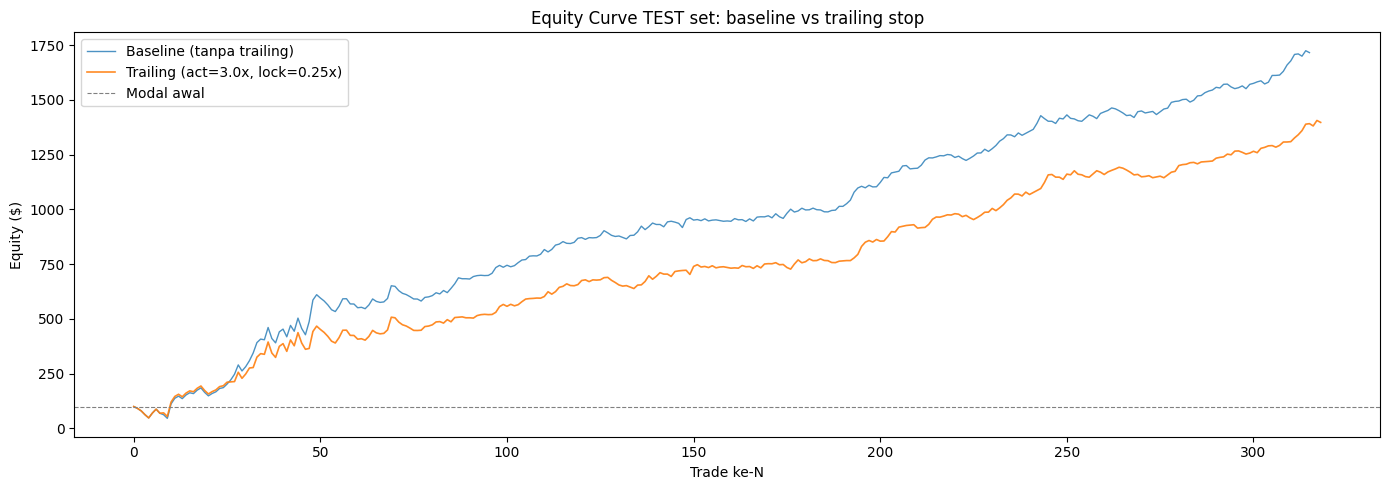

In [10]:
fig, ax = plt.subplots()
ax.plot(curve_test_baseline, label="Baseline (tanpa trailing)", alpha=0.8, linewidth=1.0)
ax.plot(curve_test_trailing, label=f"Trailing (act={ACTIVATE_MULT}x, lock={LOCK_MULT}x)", alpha=0.9, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title("Equity Curve TEST set: baseline vs trailing stop")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve_test_comparison.png", dpi=120)
plt.show()

## 9. Kesimpulan & keputusan

Kriteria: trailing stop layak dipakai kalau di TEST (out-of-sample) net_pnl & final_equity lebih
baik dari baseline TANPA trailing, DAN dampaknya bukan cuma kebetulan 1-2 trade outlier.

In [11]:
print("=== Checklist keputusan ===")
print()
print(f"1. Net PnL TEST: baseline={metrics_test_baseline['net_pnl']}, trailing={metrics_test_trailing['net_pnl']}")
better_pnl = metrics_test_trailing["net_pnl"] > metrics_test_baseline["net_pnl"]
print(f"   -> {'Trailing lebih baik' if better_pnl else 'Baseline (tanpa trailing) lebih baik/setara'}")
print()
print(f"2. Max drawdown TEST: baseline={metrics_test_baseline['max_drawdown_pct']}%, "
      f"trailing={metrics_test_trailing['max_drawdown_pct']}%")
print()
print(f"3. Konsistensi TRAIN vs TEST (final_equity dgn parameter terpilih):")
print(f"   TRAIN: {best_row['final_equity']} (vs baseline TRAIN {metrics_train_baseline['final_equity']})")
print(f"   TEST : {metrics_test_trailing['final_equity']} (vs baseline TEST {metrics_test_baseline['final_equity']})")

=== Checklist keputusan ===

1. Net PnL TEST: baseline=1615.83, trailing=1297.33
   -> Baseline (tanpa trailing) lebih baik/setara

2. Max drawdown TEST: baseline=-53.93%, trailing=-52.02%

3. Konsistensi TRAIN vs TEST (final_equity dgn parameter terpilih):
   TRAIN: 2749.42 (vs baseline TRAIN 3157.58)
   TEST : 1397.33 (vs baseline TEST 1715.83)


## 10. Simpan hasil

In [12]:
trades_test_trailing.to_csv(PROCESSED_OUT_DIR / "trade_log_test_v11.csv", index=False)
grid_df.to_csv(EXPORT_DIR / "grid_search_train_trailing.csv", index=False)
comparison_test.to_csv(EXPORT_DIR / "comparison_baseline_trailing.csv")

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Backtest v11 -- Trailing stop di atas v06 + SKIP order block\n\n")
    f.write(f"Parameter terpilih dari TRAIN grid search: activate={ACTIVATE_MULT}x ATR, lock={LOCK_MULT}x ATR\n\n")
    f.write("=== TRAIN (2025-01 s/d 2026-02) ===\n")
    f.write("Baseline (tanpa trailing):\n")
    for k, v in metrics_train_baseline.items():
        f.write(f"  {k}: {v}\n")
    f.write("Best trailing:\n")
    for k, v in best_row.items():
        f.write(f"  {k}: {v}\n")
    f.write("\n=== TEST (2026-03 s/d 2026-08, out-of-sample) ===\n")
    f.write("Baseline (tanpa trailing):\n")
    for k, v in metrics_test_baseline.items():
        f.write(f"  {k}: {v}\n")
    f.write("Trailing:\n")
    for k, v in metrics_test_trailing.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  net dampak trailing (pnl_diff sum): {merged['pnl_diff'].sum()}\n")

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v11
 - comparison_baseline_trailing.csv
 - equity_curve_test_comparison.png
 - grid_search_train_trailing.csv
 - metrics.txt
